Python file for the three computational questions 


Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

## Dataset 1

Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

The data include
- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

In [3]:
df1 = pd.read_csv("https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv")
df1.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt



Q1: Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.

In [4]:
# use the .groupby() method to call on column 'Neighbourhood ' and then by each Neighbourhood compute the average prices and scores
# use.mean() to get the average per Neighbourhood  
average_prices_by_neighborhood = df1.groupby('Neighbourhood ')[['Price', 'Review Scores Rating']].mean()
print(average_prices_by_neighborhood)

                     Price  Review Scores Rating
Neighbourhood                                   
Bronx            75.276498             91.654378
Brooklyn        127.747378             92.363497
Manhattan       183.664286             91.801496
Queens           96.857233             91.549057
Staten Island   146.166667             90.843750


In [5]:
# Print the highest average neighborhood price to see which borough is the most expensive on average
print(average_prices_by_neighborhood.max())
# based on that number, i can match that to the borough being Manhattan
print('The most expensive borough on average is Manhattan at 183.664286')

Price                   183.664286
Review Scores Rating     92.363497
dtype: float64
The most expensive borough on average is Manhattan at 183.664286


In [6]:
# create a new column called 'Log Price'
df1['Log Price'] = np.log(df1['Price'])
# print the head of the dataframe to see if the column was correctly added 
print(df1.head())

   Price  Review Scores Rating Neighbourhood  Property Type        Room Type  \
0    549                  96.0      Manhattan     Apartment     Private room   
1    149                 100.0       Brooklyn     Apartment  Entire home/apt   
2    250                 100.0      Manhattan     Apartment  Entire home/apt   
3     90                  94.0       Brooklyn     Apartment     Private room   
4    270                  90.0      Manhattan     Apartment  Entire home/apt   

   Log Price  
0   6.308098  
1   5.003946  
2   5.521461  
3   4.499810  
4   5.598422  


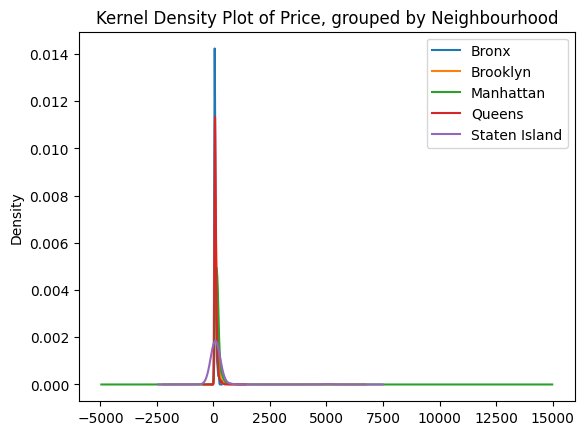

In [7]:
# group by neighborhood, price
price_kde = df1.groupby('Neighbourhood ')['Price']
# plot it as a kernel density plot
price_kde.plot.kde()
plt.title("Kernel Density Plot of Price, grouped by Neighbourhood")
# add a legend to see which color aligns with which neighbourhood 
plt.legend()


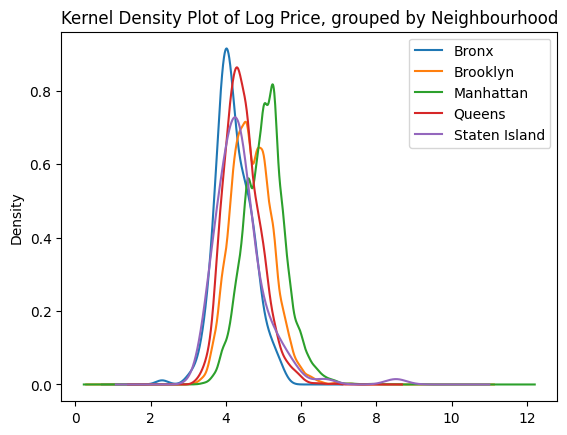

In [8]:
# group by neighborhood, log price
log_price_kde = df1.groupby('Neighbourhood ')['Log Price']
# plot it as a kernel density plot
log_price_kde.plot.kde()
plt.title("Kernel Density Plot of Log Price, grouped by Neighbourhood")
# add a legend to see which color aligns with which neighbourhood 
plt.legend()

Q2: Regress price on Neighborhood  by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?

In [9]:
# make Neighbourhood the dummy variable
# drop_first = False since we are not using an intercept so no multicorrelinearity 
dummy_variable = pd.get_dummies(df1['Neighbourhood '], drop_first=False)
# make the target variable price
regress_price = df1['Price']

In [10]:
# use the model from class to regress price on neighborhood, fit_intercept = False becuase we do not want an intercept 
# initilaize the model
model_no_intercept = LinearRegression(fit_intercept=False)
# Fit the data to the model
model_no_intercept.fit(dummy_variable, regress_price)
# call the model function .coef_ to get the coefficients
print("\nCoefficients: \n")
print(model_no_intercept.coef_)



Coefficients: 

[ 75.2764977  127.74737834 183.66428632  96.8572327  146.16666667]


In [11]:
# create a DataFrame to show side by side neighborhood name and the coefficients 
coefficients_df = pd.DataFrame({'Neighborhood': dummy_variable.columns,'Cofficients': model_no_intercept.coef_})
print("\n Coefficients DataFrame: \n")
print(coefficients_df)
# show the table from part 1
print(" \n Average Price by Neighborhood (table from above): \n")
print(average_prices_by_neighborhood)


 Coefficients DataFrame: 

    Neighborhood  Cofficients
0          Bronx    75.276498
1       Brooklyn   127.747378
2      Manhattan   183.664286
3         Queens    96.857233
4  Staten Island   146.166667
 
 Average Price by Neighborhood (table from above): 

                     Price  Review Scores Rating
Neighbourhood                                   
Bronx            75.276498             91.654378
Brooklyn        127.747378             92.363497
Manhattan       183.664286             91.801496
Queens           96.857233             91.549057
Staten Island   146.166667             90.843750


A pattern that I see is that the average score ratings are 90-92 yet the price differs by a lot. 

The coefficients in the regression are the average prices of the neighborhoods. The coefficients in a regression of a continuous variable on one categorical variable is the average/mean of that category. 

Q3: Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?


In [12]:
# make Neighbourhood the dummy variable
# drop_first = True since we are using an intercept to avoid multicorrelinearity 
dummy_variable1 = pd.get_dummies(df1['Neighbourhood '], drop_first=True)
# make the target variable price
regress_price = df1['Price']

In [13]:
# use the model from class to regress price on neighborhood, fit_intercept = True since we want an intercept 
model_intercept1 = LinearRegression(fit_intercept=True).fit(dummy_variable1, regress_price)
# get the intercept using .intercept_ from the model 
print(f"\n The intercept is:", model_intercept1.intercept_)


 The intercept is: 75.27649769585331


The intercept represents the average price in the Bronx since we dropped that column so the coefficients of the other neighborhoods are how much more expensive on average they are compared to the Bronx.

In [14]:
# call the model function .coef_ to get the coefficients
print(model_intercept1.coef_)
# create a DataFrame to show side by side neighborhood name and the coefficients 
coefficients_df1 = pd.DataFrame({'Neighborhood': dummy_variable1.columns,'Cofficients': model_intercept1.coef_})
print(" \n DataFrame to show side by side neighborhood name and the coefficient: \n")
print(coefficients_df1)


[ 52.47088065 108.38778863  21.58073501  70.89016897]
 
 DataFrame to show side by side neighborhood name and the coefficient: 

    Neighborhood  Cofficients
0       Brooklyn    52.470881
1      Manhattan   108.387789
2         Queens    21.580735
3  Staten Island    70.890169


The coefficients represent on average how much more expensive each neighborhood is from the Bronx.

So based on that, Brooklyn is $52.470881 more expensive than the Bronx on average.

In [15]:
# get the coefficients in part 2 from adding the intercept to the coefficients
# first create new variables for each neighborhood subsetting their coefficients
brooklyn_coefficient = model_intercept1.coef_[0]
manhattan_coefficient = model_intercept1.coef_[1]
queens_coefficient = model_intercept1.coef_[2]
statenisland_coefficient = model_intercept1.coef_[3]
# make the variable for intercept
intercept_df1 = model_intercept1.intercept_
# now add the intercept plus the coefficients
print("Intercept plus coefficients for each borough:")
print(intercept_df1) # this is for the bronx since i dropped it so since it is the baseline for everything else so it is just the intercept 
print(brooklyn_coefficient + intercept_df1)
print(manhattan_coefficient + intercept_df1)
print(queens_coefficient + intercept_df1)
print(statenisland_coefficient + intercept_df1)

Intercept plus coefficients for each borough:
75.27649769585331
127.74737834334832
183.66428632151684
96.85723270440279
146.16666666666694


In [16]:
# compare to coefficients in part 2
print('Coefficients in part 2:')
print(coefficients_df)

Coefficients in part 2:
    Neighborhood  Cofficients
0          Bronx    75.276498
1       Brooklyn   127.747378
2      Manhattan   183.664286
3         Queens    96.857233
4  Staten Island   146.166667


You can get the coefficients from part 2 from these new coefficients by adding the intercept to them.

Note: I added back in Bronx by just using the intercept since I dropped it for dummy variable since this model is using with_intercept=True.

Q4: Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [17]:
# Make X variable with review score ratings by neighborhood 
review_scores = df1[['Review Scores Rating']]

In [18]:
# Combine these two using pd.concat so stack two dataframes by row index (axis=1) for Review Score Rating and keep it as a DataFrame
X1 = pd.concat([review_scores, dummy_variable1], axis=1)
# Verify output as a data frame
print(f"\n X1 Head to verify output: \n {X1.head()}")
print(X1.head())
# Make y variable price
y1 = df1['Price']
print(f"\n y1 head: \n {y1.head()}")


 X1 Head to verify output: 
    Review Scores Rating  Brooklyn  Manhattan  Queens  Staten Island
0                  96.0     False       True   False          False
1                 100.0      True      False   False          False
2                 100.0     False       True   False          False
3                  94.0      True      False   False          False
4                  90.0     False       True   False          False
   Review Scores Rating  Brooklyn  Manhattan  Queens  Staten Island
0                  96.0     False       True   False          False
1                 100.0      True      False   False          False
2                 100.0     False       True   False          False
3                  94.0      True      False   False          False
4                  90.0     False       True   False          False

 y1 head: 
 0    549
1    149
2    250
3     90
4    270
Name: Price, dtype: int64


In [19]:
# Split the data using train_test_split
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)
# Initiate the model
model1_q4 = LinearRegression(fit_intercept=True)
# Fit the model on training data
model1_q4.fit(X_train1, y_train1)
# Predict on test data
y_pred_1 = model1_q4.predict(X_test1)

In [20]:
# Find R^2 and RMSE on the test set.
# Use the formulas from makeup_regression.py

mse1 = mean_squared_error(y_test1, y_pred_1)
rmse1 = np.sqrt(mse1)
print(f"Root Mean Squared Error: {rmse1}")

r2 = r2_score(y_test1, y_pred_1)
print(f"R² Score: {r2}")

Root Mean Squared Error: 140.91821103729345
R² Score: 0.045925883817350965


In [21]:
#What is the coefficient on `Review Scores Rating`? 
print(X1.columns)
# call [0] because the first coefficient corresponds to review scores rating
print(f" Review Scores Rating Coefficient: {model1_q4.coef_[0]}")
# this means that for every like point on review score, the price increases in each neighborhood by 1.2
# print all the coefficients to see how much more each neigh orhood is compared to baseline, the Bronx
print(model1_q4.coef_)

Index(['Review Scores Rating', 'Brooklyn', 'Manhattan', 'Queens',
       'Staten Island'],
      dtype='str')
 Review Scores Rating Coefficient: 1.2118517840632352
[  1.21185178  51.55597031 107.41355278  20.19857301  23.45467219]


Since the highest coefficient is 107.41355278 and that corresponds to Manhattan, the most expensive kind of property is in Manhattan. 

Q5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [22]:
# Change property type to dummy variable 
# drop_first=True to avoid multicollinearity since using intercept
property_dummies = pd.get_dummies(df1['Property Type'], drop_first=True)  
# Combine these 3 now using pd.concat, so stack three dataframes by row index (axis=1) for review_scores and property_dummies and dummy_variable1 and keep it as a DataFrame
X1_1 = pd.concat([review_scores, dummy_variable1, property_dummies], axis=1)
# Verify output as a data frame
print(f"\n X1 Head to verify output: \n {X1.head()}")
print(X1_1.head())
# Make y variable price
y1 = df1['Price']
print(f"\n y1 head: \n {y1.head()}")


 X1 Head to verify output: 
    Review Scores Rating  Brooklyn  Manhattan  Queens  Staten Island
0                  96.0     False       True   False          False
1                 100.0      True      False   False          False
2                 100.0     False       True   False          False
3                  94.0      True      False   False          False
4                  90.0     False       True   False          False
   Review Scores Rating  Brooklyn  Manhattan  Queens  Staten Island  \
0                  96.0     False       True   False          False   
1                 100.0      True      False   False          False   
2                 100.0     False       True   False          False   
3                  94.0      True      False   False          False   
4                  90.0     False       True   False          False   

   Bed & Breakfast   Boat  Bungalow  Cabin  Camper/RV  ...  Condominium  \
0            False  False     False  False      False  ...  

In [23]:
# Split the data using train_test_split
X_train1_1, X_test1_1, y_train1_1, y_test1_1 = train_test_split(X1_1, y1, test_size=0.2, random_state=42)
# Initiate the model
model1_q5 = LinearRegression(fit_intercept=True)
# Fit the model on training data
model1_q5.fit(X_train1_1, y_train1_1)
# Predict on test data
y_pred_1_1 = model1_q5.predict(X_test1_1)

In [24]:
# Find R^2 and RMSE on the test set.
# Use the formulas from makeup_regression.py

mse1_1 = mean_squared_error(y_test1_1, y_pred_1_1)
rmse1_1 = np.sqrt(mse1_1)
print(f"Root Mean Squared Error: {rmse1_1}")

r2_1 = r2_score(y_test1_1, y_pred_1_1)
print(f"R² Score: {r2_1}")

# check column names to see for indexing for review score rating
print(X1_1.columns)

# Cofficient for review score ratintg
print(f"\n Coefficient for Review Score Rating:, {model1_q5.coef_[0]} \n")

# all coefficients for each column
print(model1_q5.coef_)

Root Mean Squared Error: 140.30266238276283
R² Score: 0.054242713551245325
Index(['Review Scores Rating', 'Brooklyn', 'Manhattan', 'Queens',
       'Staten Island', 'Bed & Breakfast', 'Boat', 'Bungalow', 'Cabin',
       'Camper/RV', 'Castle', 'Chalet', 'Condominium', 'Dorm', 'House', 'Hut',
       'Lighthouse', 'Loft', 'Other', 'Townhouse', 'Treehouse', 'Villa'],
      dtype='str')

 Coefficient for Review Score Rating:, 1.2010106602298556 

[   1.20101066   59.63370248  121.00552006   26.83061694   15.70097372
  -28.70392015   47.07041892   83.97244024   12.38962146  -13.8171252
  -41.81054816  -30.23771992   61.90716215  -42.27775811   34.71134649
 -134.6044842   -91.43873058   69.8910245    49.24976096   44.11076797
   10.32518207   33.90146833]


Q6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.

The coefficient on Review Scores Rating changed from 1.212 in part 4 to 1.201 in part 5. The review score coefficient is more accurate in part 5 because when we added property type as a variable, it separated the property type effect from the review score effect. 


Q7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?


# Dataset 2

This question is a case study for linear models. The data are about car prices. In particular, they include:

- Price, Color, Seating_Capacity
- Body_Type: crossover, hatchback, muv, sedan, suv
- Make, Make_Year: The brand of car and year produced
- Mileage_Run: The number of miles on the odometer
- Fuel_Type: Diesel or gasoline/petrol
- Transmission, Transmission_Type: speeds and automatic/manual

Q1: Load cars_hw.csv. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.

In [59]:
Cars = pd.read_csv("cars_hw.csv")
print(Cars.head())
print(Cars.info())

   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000  
<class 'pandas.DataFrame'>
Range

In [60]:
# View column names
Cars.columns

Index(['Unnamed: 0', 'Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run',
       'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission',
       'Transmission_Type', 'Price'],
      dtype='str')

In [61]:
# Drop column 'Unnamed: 0' becuase useless
Cars.drop(columns="Unnamed: 0", inplace=True)

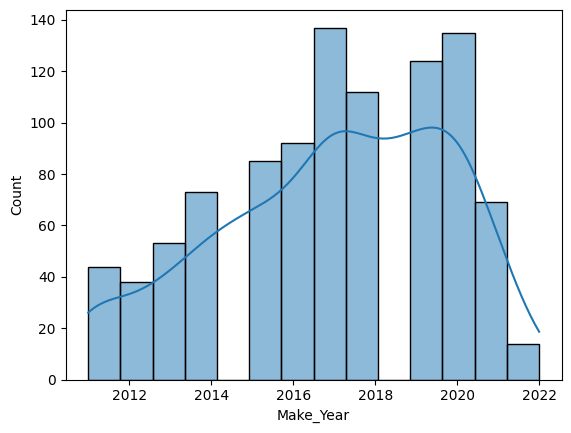

In [62]:
# look at distribution for numeric cols to see if normal distribution or if i need to transform them
sns.histplot(Cars['Make_Year'], kde=True)
plt.show()

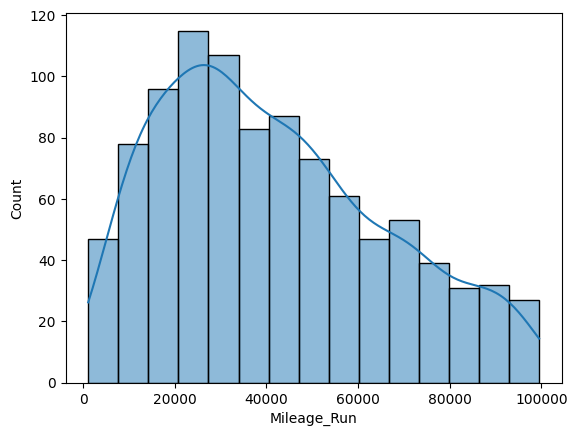

In [63]:
sns.histplot(Cars['Mileage_Run'], kde=True)
plt.show()

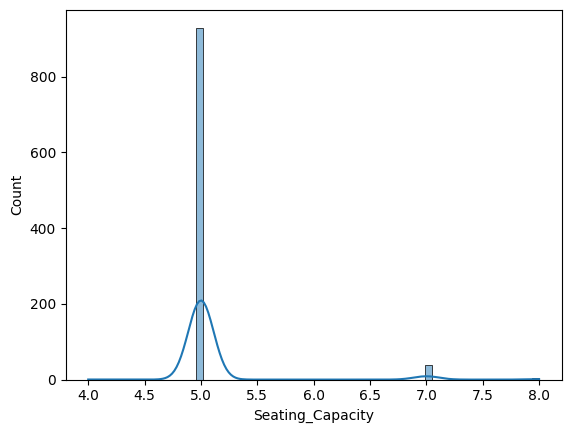

In [64]:
sns.histplot(Cars['Seating_Capacity'], kde=True)
plt.show()
# Drop becuase lowkey useless
Cars.drop(columns = 'Seating_Capacity', inplace=True)

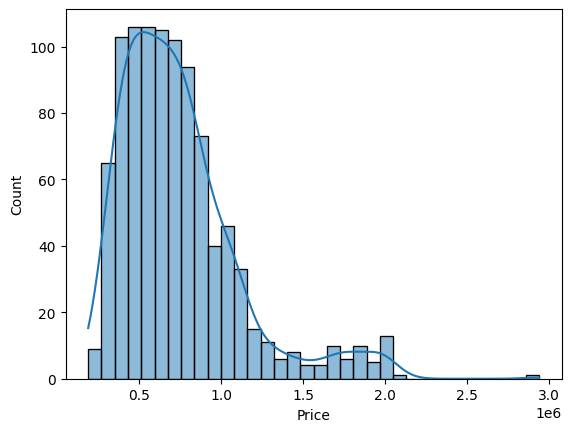

In [65]:
sns.histplot(Cars['Price'], kde=True)
plt.show()

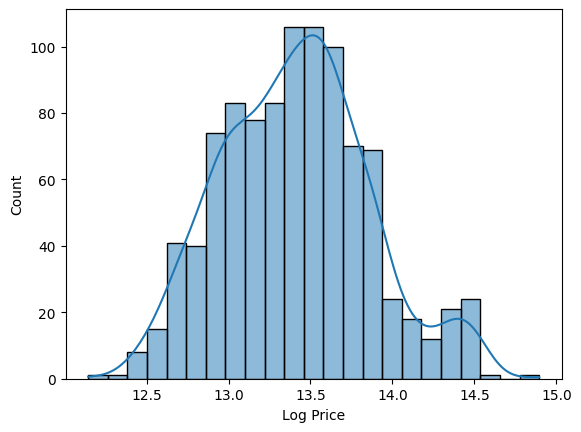

In [66]:
# apply log transformaiton to this 
Cars['Log Price'] = np.log(Cars['Price'])
# plot it now
sns.histplot(Cars['Log Price'], kde=True)
plt.show()
# drop origional price column
Cars.drop(columns='Price', inplace=True)

In [67]:
# Verify numeric drops / changes
Cars.columns

Index(['Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run',
       'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type',
       'Log Price'],
      dtype='str')

In [100]:
# EDA for categorical data
# for categorical data in Linear Regression, convert all to dummy 
categorical_cols = ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type']
cat_dummies = pd.get_dummies(Cars[categorical_cols], drop_first=True)
print(cat_dummies)

     Make_Datsun  Make_Ford  Make_Honda  Make_Hyundai  Make_Jeep  Make_Kia  \
0          False      False       False         False      False     False   
1          False      False       False          True      False     False   
2          False      False        True         False      False     False   
3          False      False       False         False      False     False   
4          False      False       False          True      False     False   
..           ...        ...         ...           ...        ...       ...   
971        False      False       False          True      False     False   
972        False      False       False          True      False     False   
973        False      False       False          True      False     False   
974        False       True       False         False      False     False   
975        False      False       False         False      False     False   

     Make_MG Motors  Make_Mahindra  Make_Maruti Suzuki  Make_Ni

Q2: Summarize the Price variable and create a kernel density plot. Use .groupby() and .describe() to summarize prices by brand (Make). Make a grouped kernel density plot by Make. Which car brands are the most expensive? What do prices look like in general?

In [101]:
# use grupby() and describe() to summarize prices by brad
Price_By_Brand = Cars.groupby('Make')['Log Price']
print(Price_By_Brand.describe())

               count       mean       std        min        25%        50%  \
Make                                                                         
Chevrolet        6.0  12.919895  0.480975  12.495004  12.568392  12.752286   
Datsun           3.0  12.576047  0.036311  12.538967  12.558302  12.577636   
Ford            52.0  13.468280  0.210895  12.577636  13.361380  13.469493   
Honda           73.0  13.536318  0.336972  12.663497  13.272506  13.573439   
Hyundai        305.0  13.368511  0.398781  12.421184  13.091904  13.366094   
Jeep             4.0  14.216591  0.105084  14.070153  14.183270  14.240265   
Kia              8.0  14.292177  0.076877  14.129591  14.272242  14.303105   
MG Motors       35.0  14.439052  0.066263  14.278615  14.395744  14.429615   
Mahindra        18.0  13.898953  0.159906  13.587354  13.851808  13.905680   
Maruti Suzuki  293.0  13.218132  0.371409  12.375815  12.926348  13.174956   
Nissan           4.0  13.641194  0.392610  13.071070  13.537775 

Prices look to be...
The most expensive car brands are MG Motors, Kia, and Jeep.

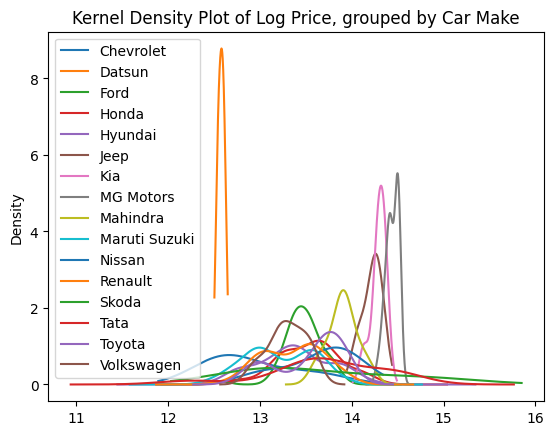

In [102]:
# plot it as a kernel density plot
Price_By_Brand.plot.kde()
# add title
plt.title("Kernel Density Plot of Log Price, grouped by Car Make")
# add a legend to see which color aligns with which neighbourhood 
plt.legend()

In [103]:
# get top 3 most expensive
sort_cars_order_price = Cars.groupby('Make')['Log Price'].mean().sort_values(ascending=False)
print(sort_cars_order_price)


Make
MG Motors        14.439052
Kia              14.292177
Jeep             14.216591
Mahindra         13.898953
Tata             13.713405
Nissan           13.641194
Skoda            13.640864
Honda            13.536318
Toyota           13.535507
Ford             13.468280
Hyundai          13.368511
Renault          13.350862
Volkswagen       13.294742
Maruti Suzuki    13.218132
Chevrolet        12.919895
Datsun           12.576047
Name: Log Price, dtype: float64


The top 3 most expensive cars are MG Motors, Kia, and Jeep. Prices in general appear to have a wide range and to be priced near the median.

Q3: Split the data into an 80% training set and a 20% testing set.

In [110]:
# Create x and y 
X_numeric = Cars[['Make_Year', 'Mileage_Run']]
y = Cars['Log Price']
# Split the data using train_test_split
X_train_num, X_test_num, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42)

Q4:Make a model where you regress price on the numeric variables alone; what is the $R^2$ and RMSE on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use pd.get_dummies(); be careful of the dummy variable trap); what is the $R^2$ and RMSE on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and RMSE on the test set? Does the joint model perform better or worse, and by home much?

Model 1: Numeric Variables

In [111]:
# initiate and fit model 
model_num = LinearRegression()
model_num.fit(X_train_num, y_train)

# predict 
y_train_pred_num = model_num.predict(X_train_num)
y_test_pred_num = model_num.predict(X_test_num)

# evaluate RMSE and R^2 for test adn train 
rmse_train_num = np.sqrt(mean_squared_error(y_train, y_train_pred_num))
r2_train_num = r2_score(y_train, y_train_pred_num)

rmse_test_num = np.sqrt(mean_squared_error(y_test, y_test_pred_num))
r2_test_num = r2_score(y_test, y_test_pred_num)

print("Numeric Model")
print("Train R²:", r2_train_num)
print("Test R²:", r2_test_num)
print("Train RMSE:", rmse_train_num)
print("Test RMSE:", rmse_test_num)

Numeric Model
Train R²: 0.40823301721717753
Test R²: 0.37719591878528314
Train RMSE: 0.3484552107859107
Test RMSE: 0.34463149857333997


The RMSE and R^2 on the training and test set are:

Train R²: 0.40823301721717753
Train RMSE: 0.3484552107859107

Test R²: 0.37719591878528314
Test RMSE: 0.34463149857333997

Model 2: Categorical

In [116]:
# resplit using categorical x test and train
X_train_cat, X_test_cat, y_train, y_test = train_test_split(cat_dummies, y, test_size=0.2, random_state=42)


In [117]:
# initiate and fit model 
model_cat = LinearRegression()
model_cat.fit(X_train_cat, y_train)

# predict 
y_train_pred_cat = model_cat.predict(X_train_cat)
y_test_pred_cat = model_cat.predict(X_test_cat)

# evaluate RMSE and R^2 for test adn train 
rmse_train_cat = np.sqrt(mean_squared_error(y_train, y_train_pred_cat))
r2_train_cat = r2_score(y_train, y_train_pred_cat)

rmse_test_cat = np.sqrt(mean_squared_error(y_test, y_test_pred_cat))
r2_test_cat = r2_score(y_test, y_test_pred_cat)

print("Categorical Model")
print("Train R²:", r2_train_cat)
print("Test R²:", r2_test_cat)
print("Train RMSE:", rmse_train_cat)
print("Test RMSE:", rmse_test_cat)

Categorical Model
Train R²: 0.6877005669825762
Test R²: 0.6535045874136006
Train RMSE: 0.2531379134684625
Test RMSE: 0.2570561437633287


The RMSe and R^2 on the test set is:

Test R²: 0.6535045874136006 Test RMSE: 0.2570561437633287

In [121]:
# Compare model performance on test set 
print("Model 1 Test R²:", r2_test_num)
print("Model 2 Test R²:", r2_test_cat)


print("Model 1 Test RMSE:", rmse_test_num)
print("Model 2 Test RMSE:", rmse_test_cat)


Model 1 Test R²: 0.37719591878528314
Model 2 Test R²: 0.6535045874136006
Model 1 Test RMSE: 0.34463149857333997
Model 2 Test RMSE: 0.2570561437633287


Model 2 performed better on the test set becuase the RMSE is lower and the R^2 is higher so it was a better fit and is more accurate.

Model 3: Numerical and Categorical Combine

In [118]:
# combine
X_combined = pd.concat([X_numeric, cat_dummies], axis=1)
# train test split
X_train_comb, X_test_comb, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)


In [ ]:
# initiate and fit model 
model_comb = LinearRegression()
model_comb.fit(X_train_comb, y_train)


# predict 
y_train_pred = model_comb.predict(X_train_comb)
y_test_pred = model_comb.predict(X_test_comb)

# evaluate RMSE and R^2 for test adn train 
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)


print("Combine Model")
print("Train R²:", r2_train)
print("Test R²:", r2_test)
print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_test)

Combine Model
Train R²: 0.8259025067577067
Test R²: 0.8034183405152346
Train RMSE: 0.18900263419204857
Test RMSE: 0.19362023462530906


The R^2 and RMSE on the test set is: 

Test R²: 0.8034183405152346 Test RMSE: 0.19362023462530906

In [ ]:
# compare all 3 models 
print("Model 1 Test R²:", r2_test_num)
print("Model 2 Test R²:", r2_test_cat)
print("Model 3 Test R²:", r2_test)


print("Model 1 Test RMSE:", rmse_test_num)
print("Model 2 Test RMSE:", rmse_test_cat)
print("Model 3 Test RMSE:", rmse_test)

Model 1 Test R²: 0.37719591878528314
Model 2 Test R²: 0.6535045874136006
Model 3 Test R²: 0.8034183405152346
Model 1 Test RMSE: 0.34463149857333997
Model 2 Test RMSE: 0.2570561437633287
Model 3 Test RMSE: 0.19362023462530906


The joint model performs better on the test set than model 1 and model 2. This is becuase its RMSE is the lowest, at 0.19 and R^2 is the highest at 0.8. It performs better in RMSE by 0.1-0.2 and R^2 by 0.2-0.5

Q5: Use the PolynomialFeatures function from sklearn to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and RMSE change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and RMSE? How does it compare to your best model from part 4?

In [125]:
# create variables called degrees and results
degrees = [1,2,3,4,5,6,7,8]
results = []

# write a for loop so it does everytjing done in the previous step but for all degrees and store the resulting R^2 and RMSE in results along with additional info

for d in degrees:
    # use sklearn PolynomialFeatres function 
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_num)
    X_test_poly = poly.transform(X_test_num)
    
    # fit and initiate model 
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # predict model 
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    # R^2 and RMSE calculations 
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # add this to list results for each degree
    results.append({
        'Degree': d,
        'R2_train': r2_train,
        'R2_test': r2_test,
        'RMSE_train': rmse_train,
        'RMSE_test': rmse_test
    })

# print results to see information for each degree
print(results)
# ok so that looked ugly so instead make it a dataframe so easier to read
results_df = pd.DataFrame(results)
# now repring results
print(results_df)

[{'Degree': 1, 'R2_train': 0.40823301721717753, 'R2_test': 0.37719591878528314, 'RMSE_train': np.float64(0.3484552107859107), 'RMSE_test': np.float64(0.34463149857333997)}, {'Degree': 2, 'R2_train': 0.4186044375356496, 'R2_test': 0.4027921971251125, 'RMSE_train': np.float64(0.34538816694574775), 'RMSE_test': np.float64(0.3374752908396325)}, {'Degree': 3, 'R2_train': 0.42231084890545434, 'R2_test': 0.39737160359921686, 'RMSE_train': np.float64(0.3442854775813779), 'RMSE_test': np.float64(0.33900338886866666)}, {'Degree': 4, 'R2_train': 0.4281163670986662, 'R2_test': 0.39097957731490884, 'RMSE_train': np.float64(0.34255115156648963), 'RMSE_test': np.float64(0.3407965360054354)}, {'Degree': 5, 'R2_train': 0.4266421064173529, 'R2_test': 0.3823457505614044, 'RMSE_train': np.float64(0.34299239924115593), 'RMSE_test': np.float64(0.34320369937416617)}, {'Degree': 6, 'R2_train': 0.42751273789112665, 'R2_test': 0.38750924991481694, 'RMSE_train': np.float64(0.34273188706410046), 'RMSE_test': np.f

As I increase the degree, the R^2 value increases and then decreases around degree 5 for train. For test it increases until degree 1 and then decreases. For RMSE train it decreases until degree 5 and then increases and for test it decreases until degree 1 and then increases and then decreases slighyly and then increases slighyly. R^2 never went negative on my test set. 

Honestly it compares poorly to my best model, model 3(combine numeric and categorical) since these RMSE are higher and R^2 is lower. 

Q6: For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

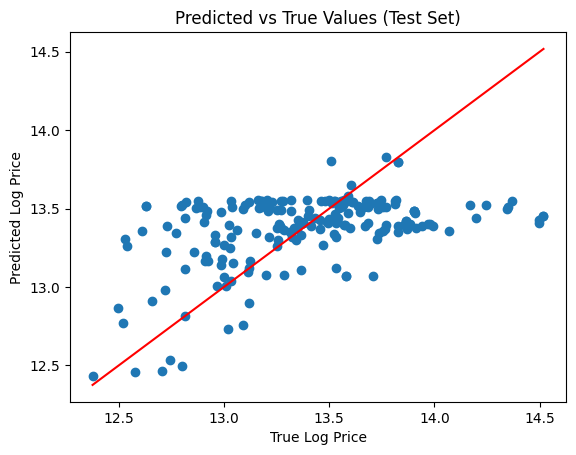

In [129]:
# plot y_test_pred and y_test for model 3
plt.scatter(y_test, y_test_pred)
# add in diagonal line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.xlabel('True Log Price')
plt.ylabel('Predicted Log Price')
plt.title('Predicted vs True Values (Test Set)')
plt.show()

So the predicted and true values do not roughly line up along the diagonal that well.

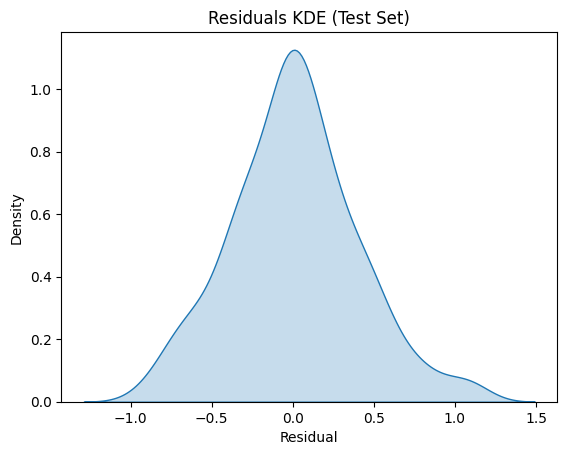

In [132]:
# plot resuduals as kde

residuals = y_test - y_test_pred

sns.kdeplot(residuals, fill=True)
plt.xlabel('Residual')
plt.title('Residuals KDE (Test Set)')
plt.show()


I would say yes the residuals look roughlt bell shaped around 0.

Strengths:
The R^2 is high at 0.8 so 80% of the variance in log car prices (R^2 =0.8) and has a low RMSE of (0.19). This indicated that it is a solid fit and pretty accurate. Lastly, the residuals are roughlt centered around 0 and mostly summetric.

Weaknesses:
I dropped Seat Capacity origionally so I wonder if RMSE would be lower and R^2 would be higher if I kept that in. The predicted vs true values on the test set don’t align closely with the diagonal, meaning individual predictions can deviate noticeably from actual prices. Expensive cars are not predicted as accurately.

# Dataset 3

Q1: Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.

Q2: Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.

Q3: Split the sample into an ~80% training set and a ~20% test set.

Q4: Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.

Q5: Which model performed the best, and why?

#6: What did you learn?